In [1]:
# We start by importing all the necessary packages
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import torch
from tqdm import tqdm
import math
from Python_files import time_integration_functions as TST
from Python_files import TLM_Test as TT
from Python_files import ETLM as ETLMC
from Python_files import LETLM_ensemble as LETLMC
from Python_files import IETLM_ensemble as IETLMC
from Python_files import GETLM as GETLMC


#  We also need to set the precision to be higher as we are working with very small perturbations
torch.set_default_dtype(torch.float64)


In [2]:
# We will start by looking at Crank-Nicolson
# The first step is to the parameters for out model

N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.1 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.CN_L96
x_values = np.arange(1, N+1)  
spin_up_time = 1000

In [3]:
# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
# We then run the model so that the Lorenz 96 model has reached it's 'equilibrium'
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)

100%|██████████| 999/999 [00:00<00:00, 12149.01it/s]


In [4]:
# Now that the model is spun up, we need to generate the ensembles

# The first step to do this is to work out what we want to use as our stencil
stencil_members_future_CN = [-2,-1,0,1]
stencil_members_current_CN = [-2,-1,0,1]
stencil_members_past_CN = [-2,-1,0,1]
stencil_members_large_CN = [stencil_members_future_CN, stencil_members_current_CN, stencil_members_past_CN]

# Now that we have our stencil we can calculate how many ensemble members we need 
ensemble_size_CN = 5 + len(stencil_members_future_CN) + len(stencil_members_current_CN) + len(stencil_members_past_CN)

# We now need to set the size of the perturbation that we will use for generating the ensemble TLMS
SD_pert = 10**(-7)

# We also need to define our test perturbation
Test_pert_current = torch.randn(N) * SD_pert
Test_pert_past = torch.randn(N) * SD_pert
Test_pert = (Test_pert_current, Test_pert_past)


test_final_pert, Ensemble_final, Ensembles, test_guess, unpert_run=  GETLMC.GETLM_ensemble_generator_mult(x_out, ensemble_size_CN, SD_pert, model, model_parameters, Test_pert, number_of_steps = 10)


In [5]:
IETLM_STENCIL_LARGE = [[-2,-1,0,1],[-2,-1,0,1]]
LETLM_STENCIL_LARGE = [[0],[-3,-2,-1,0,1,2,3]]


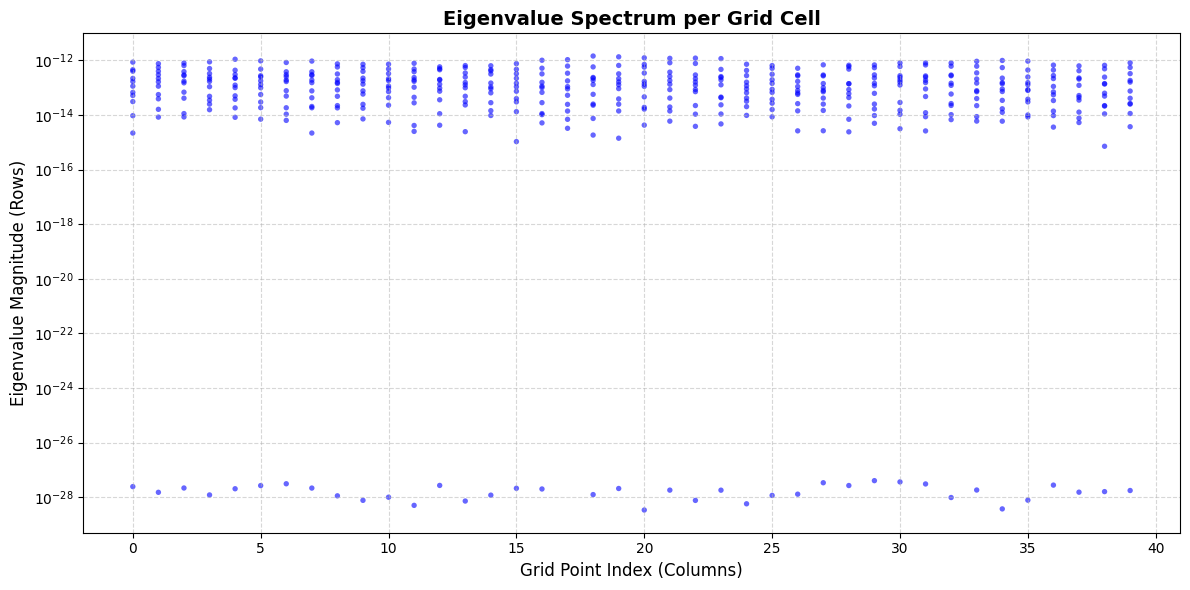

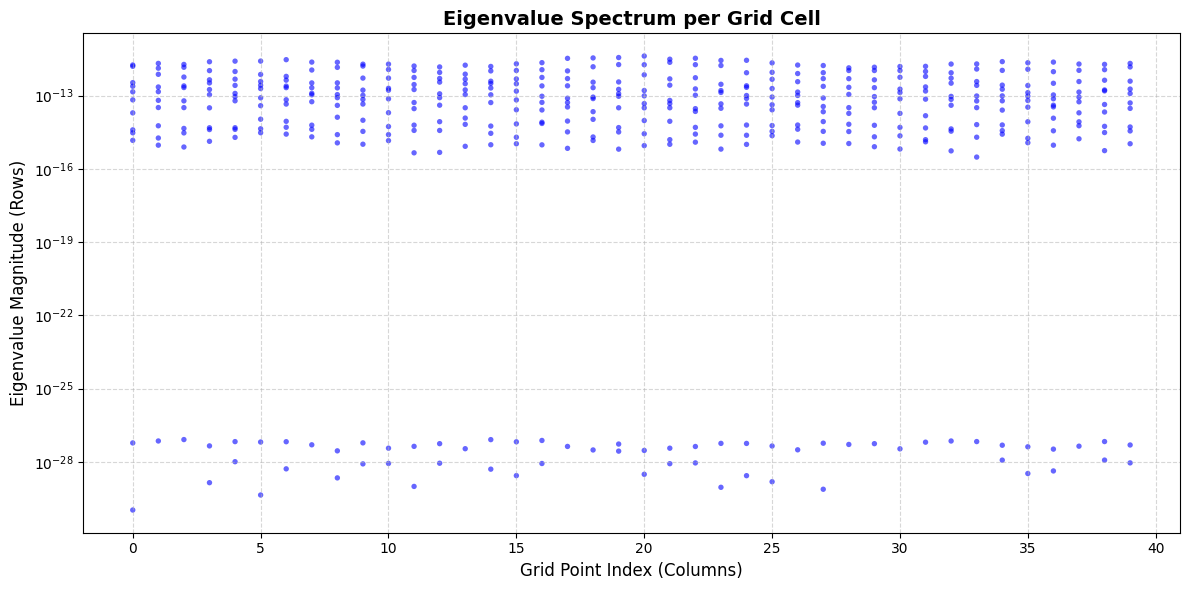

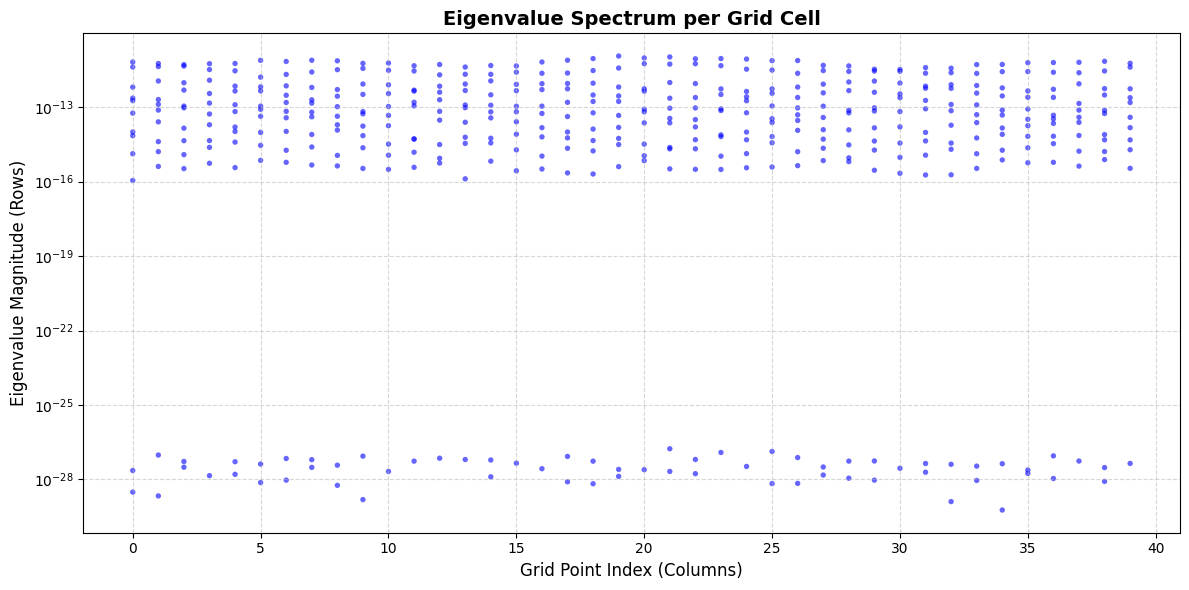

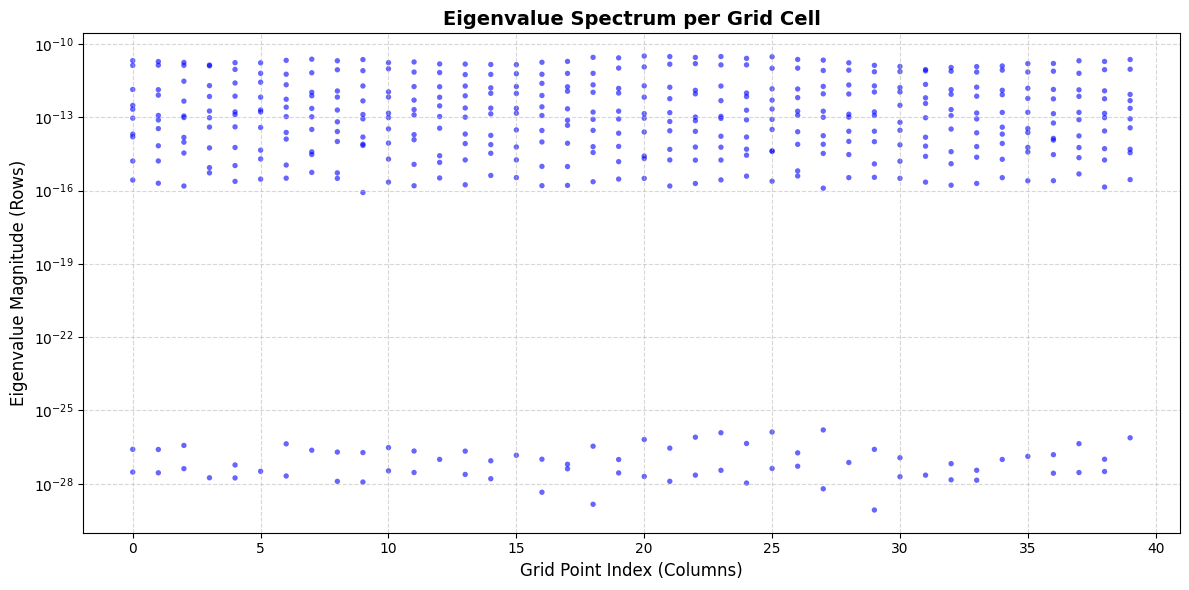

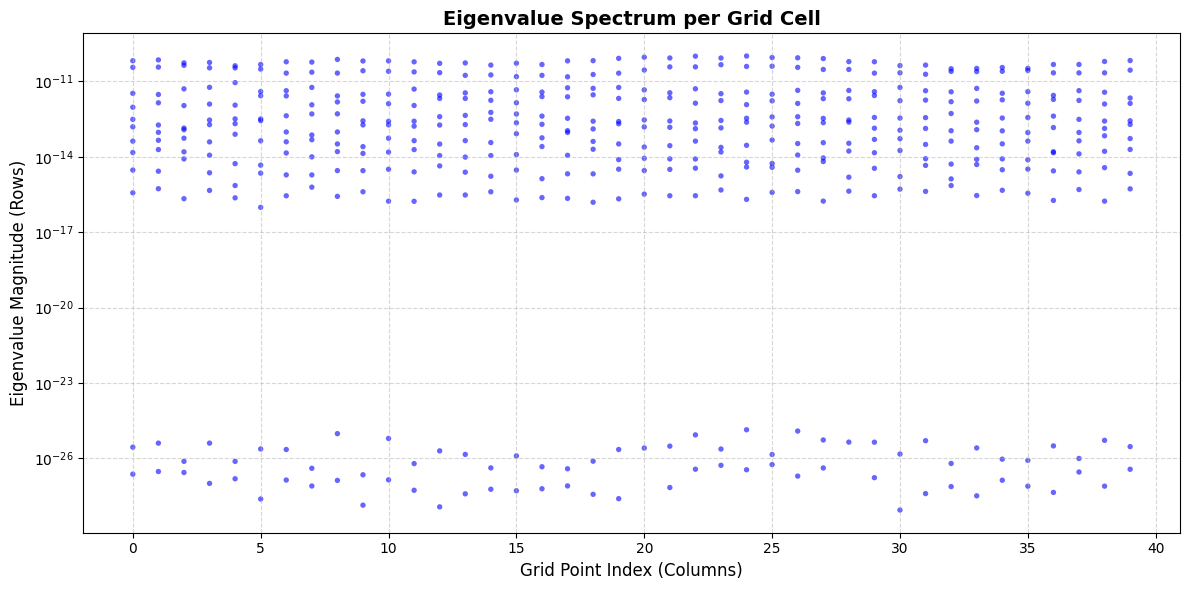

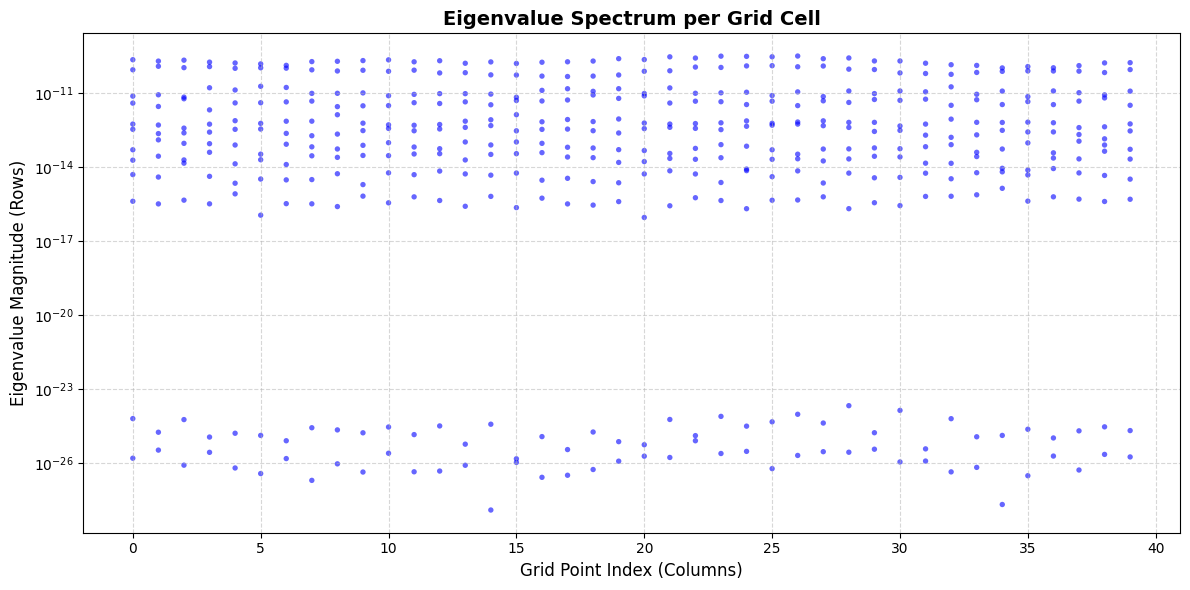

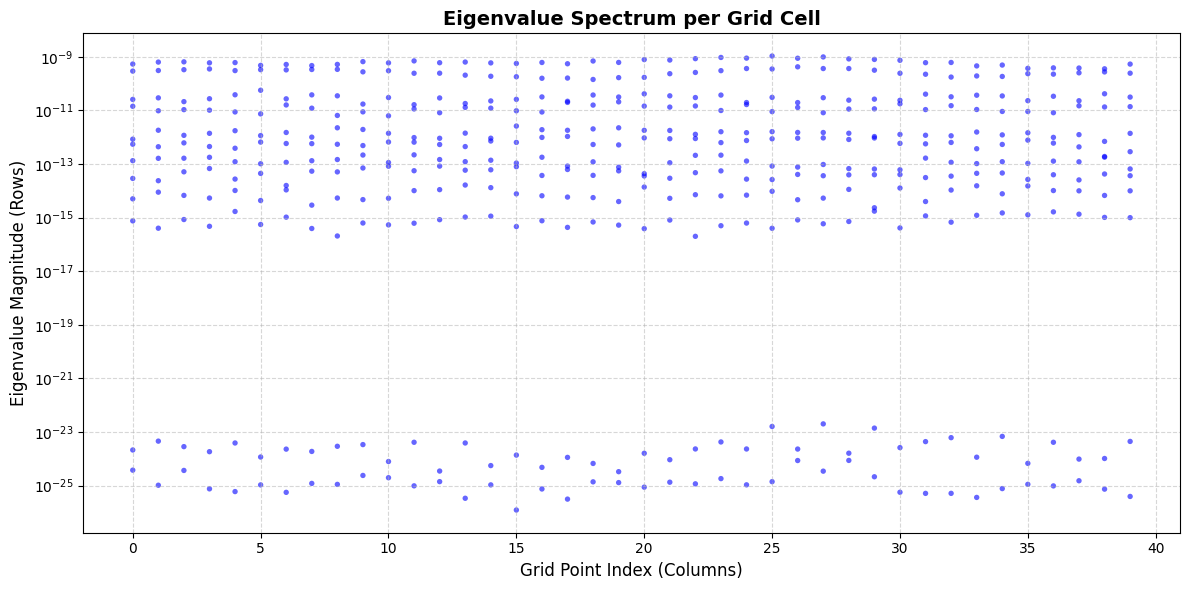

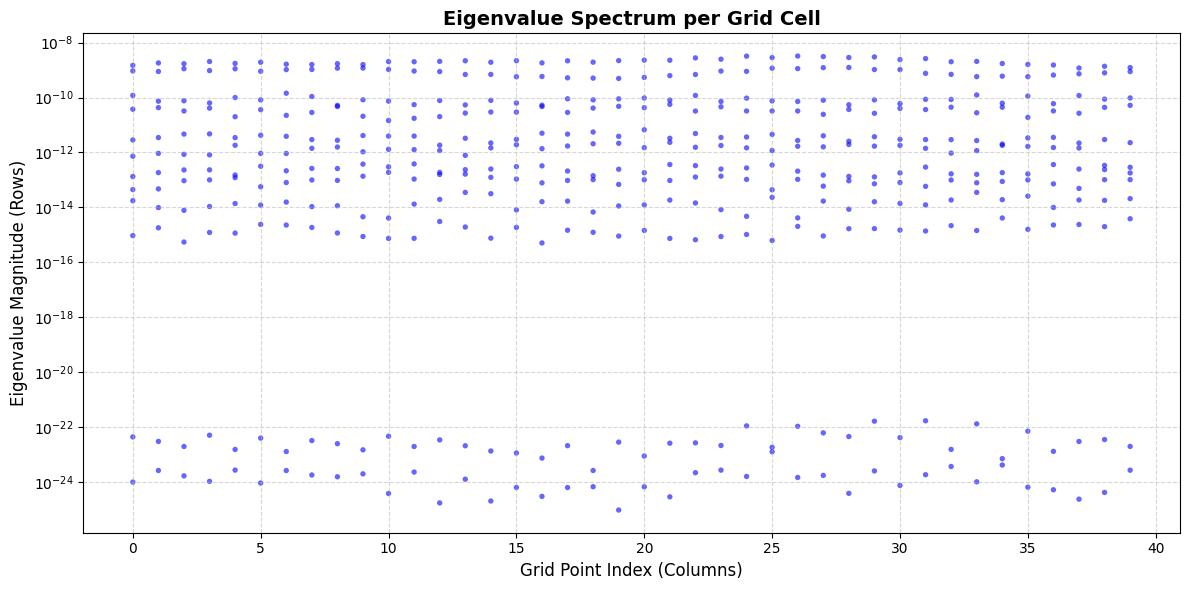

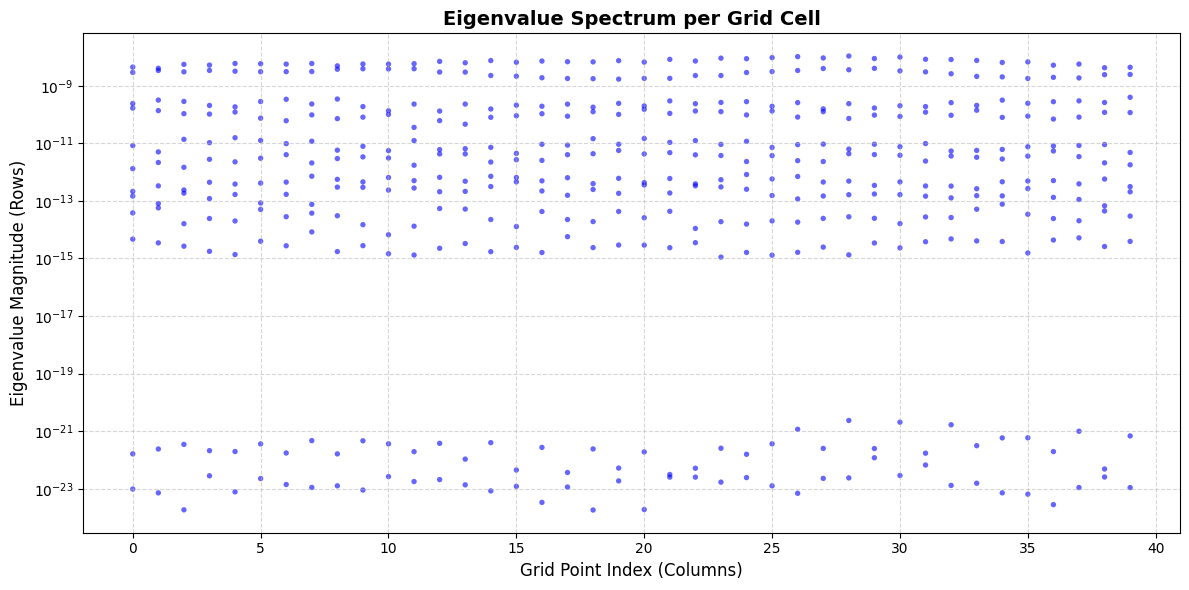

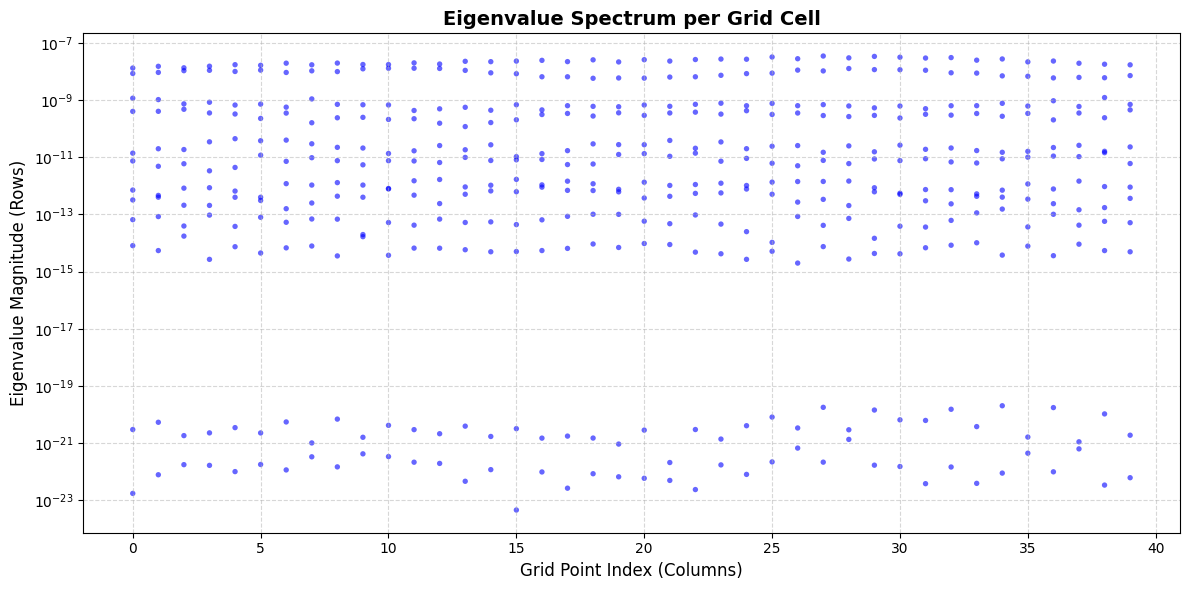

In [6]:
# Now that we have our ensembles generated we need to generate the LETLM, IETLM and GETLM for each time step
GETLMS = []
IETLMS = []
LETLMS = []

for i in range(len(Ensemble_final)-2):
    # We start by selecting the ensembles at each time level
    Chi = Ensemble_final[i+2]  # Future step matrix (N, ensemble_size)
    Xi  = Ensemble_final[i+1]  # Current step matrix (N, ensemble_size)
    X   = Ensemble_final[i]
    k = 2 # number of zero eigenvalue eigenvalues

    # We now make the GETLM
    N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_CN, model_parameters, ensemble_size_CN, k, plot = True)
    GETLMS.append([N_tilde_G, L_tilde_G, K_tilde_G])

    # We will now make the IETLM
    N_tilde_I, L_tilde_I = IETLMC.IETLM_generator(Chi, Xi, IETLM_STENCIL_LARGE, model_parameters, ensemble_size_CN)
    IETLM_temp = torch.pinverse(N_tilde_I) @ L_tilde_I
    IETLMS.append(IETLM_temp)

    # We will now make the LETLM
    M_tilde = LETLMC.LETLM_generator(Chi, Xi, LETLM_STENCIL_LARGE, model_parameters, ensemble_size_CN)
    LETLMS.append(M_tilde)


In [7]:
# Updated Cell 7
def experiment(test_final_pert, test_guess, unpert_run, GETLMS, IETLMS, LETLMS):
    # We first set a starting point for the TLMS
    starting_time = 1

    LETLM_TT_result = ()
    IETLM_TT_result = ()
    GETLM_TT_result = ()

    # The first step is to get the test perturbation and then copy it for the IETLM, LETlM and GETLM 
    test_0 = test_final_pert[1+starting_time]
    LETLM_test = test_0
    IETLM_test = test_0
    GETLM_test_future = test_0
    GETLM_test_current = test_final_pert[starting_time]

    index = 1+starting_time

    LETLM_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )
    IETLM_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )
    GETLM_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )

    LETLM_TT_result += (LETLM_TT,)
    IETLM_TT_result += (IETLM_TT,)
    GETLM_TT_result += (GETLM_TT,)

    # We will now go through the steps to see how each of the TLMS goes 
    for i in range(len(test_final_pert)-3):
        index = i+2 + starting_time
        test = test_final_pert[i+2 + starting_time]
        
        letlm = LETLMS[i+starting_time][0]
        LETLM_test = letlm @ LETLM_test
        letlm_tt = TT.TLM_test(test_guess[index], unpert_run[index], LETLM_test)
        LETLM_TT_result+=(letlm_tt,)

        # Ploting the IETLM
        ietlm = IETLMS[i+starting_time]
        IETLM_test = ietlm @ IETLM_test
        ietlm_tt = TT.TLM_test(test_guess[index], unpert_run[index], IETLM_test)
        IETLM_TT_result +=(ietlm_tt,)

        GETLM_test_past = GETLM_test_current
        GETLM_test_current = GETLM_test_future

        NL = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][1]
        NK = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][2]
        GETLM_test_future = NL @ GETLM_test_current + NK @ GETLM_test_past

        getlm_tt = TT.TLM_test(test_guess[index], unpert_run[index], GETLM_test_future)
        GETLM_TT_result +=(getlm_tt,)

    return GETLM_TT_result, IETLM_TT_result, LETLM_TT_result

In [8]:
# # We will now compare the TLMS to the actual data to see 

# def experiment():

#     # We first set a starting point for the TLMS
#     starting_time = 1

#     x_values = np.arange(1, N + 1)


#     LETLM_TT_result = ()
#     IETLM_TT_result = ()
#     GETLM_TT_result = ()


#     # The first step is to get the test perturbation and then copy it for the IETLM, LETlM and GETLM 
#     test_0 = test_final_pert[1+starting_time]
#     LETLM_test = test_0
#     IETLM_test = test_0
#     GETLM_test_future = test_0
#     GETLM_test_current = test_final_pert[starting_time]


#     index = 1+starting_time

#     LETLM_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )
#     IETLM_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )
#     GETLM_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )

#     # print(LETLM_TT)
#     LETLM_TT_result += (LETLM_TT,)
#     IETLM_TT_result += (IETLM_TT,)
#     GETLM_TT_result += (GETLM_TT,)







#     # We will now go through the steps to see how each of the TLMS goes 
#     for i in range(len(test_final_pert)-3):
#         index = i+2 + starting_time
#         test = test_final_pert[i+2 + starting_time]
#         letlm = LETLMS[i+starting_time][0]
#         # print(len(letlm))
#         LETLM_test = letlm @ LETLM_test

#         letlm_tt = TT.TLM_test(test_guess[index], unpert_run[index], LETLM_test)
#         # print(letlm_tt)
#         LETLM_TT_result+=(letlm_tt,)
#         # LETLM_TT = torch.cat((LETLM_TT, letlm_tt), dim = 0)


#         # Ploting the IETLM
#         ietlm = IETLMS[i+starting_time]
#         IETLM_test = ietlm @ IETLM_test


#         ietlm_tt = TT.TLM_test(test_guess[index], unpert_run[index], IETLM_test)
#         IETLM_TT_result +=(ietlm_tt,)


#         # IETLM_TT = torch.cat((IETLM_TT, ietlm_tt), dim = 0)



#         GETLM_test_past = GETLM_test_current
#         GETLM_test_current = GETLM_test_future

#         NL = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][1]
#         NK = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][2]
#         GETLM_test_future = NL @ GETLM_test_current + NK @ GETLM_test_past

#         getlm_tt = TT.TLM_test(test_guess[index], unpert_run[index], GETLM_test_future)

#         # GETLM_TT = torch.cat((GETLM_TT, getlm_tt), dim = 0)
#         GETLM_TT_result +=(getlm_tt,)


#     return GETLM_TT_result, IETLM_TT_result, LETLM_TT_result


In [9]:
# Updated Cell 8
def testing_multi_trials(num_trials, model, model_parameters, spin_up_time, stencil_members_large_GETLM,stencil_members_large_IETLM, stencil_members_large_LETLM, ensemble_size, SD_pert, num_steps,k):

    # Step 0: Create variables to store the data. 
    # Set to None initially so we can dynamically size them based on num_steps
    total_GETLM_error = None
    total_IETLM_error = None
    total_LETLM_error = None
    
    LETLM_vs_IETLM = 0
    GETLM_vs_IETLM = 0
    GETLM_vs_LETLM = 0

    # Step 1: Unpack the model parameters
    (N, dx, dt, alpha, beta, F_L96) = model_parameters

    # Step 2: Spin up the model
    x_in = torch.randn(N,1)

    for i in range(spin_up_time-1):
        x_in = TST.run_model(x_in, model, model_parameters)
    x_out = TST.run_model(x_in, model, model_parameters)

    # Step 3
    for trial in tqdm(range(num_trials)):
        torch.manual_seed((trial*2)**4)
        
        Test_pert_current = torch.randn(N) * SD_pert
        Test_pert_past = torch.randn(N) * SD_pert
        Test_pert = (Test_pert_current, Test_pert_past)

        test_final_pert, Ensemble_final, Ensembles, test_guess, unpert_run=  GETLMC.GETLM_ensemble_generator_mult(x_out, ensemble_size_CN, SD_pert, model, model_parameters, Test_pert, number_of_steps = num_steps)

        GETLMS = []
        IETLMS = []
        LETLMS = []

        for i in range(len(Ensemble_final)-2):
            Chi = Ensemble_final[i+2]  
            Xi  = Ensemble_final[i+1]  
            X   = Ensemble_final[i]

            N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_CN, model_parameters, ensemble_size_CN, k, plot = False)
            GETLMS.append([N_tilde_G, L_tilde_G, K_tilde_G])

            N_tilde_I, L_tilde_I = IETLMC.IETLM_generator(Chi, Xi, IETLM_STENCIL_LARGE, model_parameters, ensemble_size_CN)
            IETLM_temp = torch.pinverse(N_tilde_I) @ L_tilde_I
            IETLMS.append(IETLM_temp)

            M_tilde = LETLMC.LETLM_generator(Chi, Xi, LETLM_STENCIL_LARGE, model_parameters, ensemble_size_CN)
            LETLMS.append(M_tilde)

        # Pass the dynamically generated variables from this specific trial to the experiment
        GETLM_TT_result, IETLM_TT_result, LETLM_TT_result = experiment(test_final_pert, test_guess, unpert_run, GETLMS, IETLMS, LETLMS)

        # Convert tuples of PyTorch tensors to flat NumPy arrays
        getlm_arr = np.array([t.item() for t in GETLM_TT_result])
        ietlm_arr = np.array([t.item() for t in IETLM_TT_result])
        letlm_arr = np.array([t.item() for t in LETLM_TT_result])

        # If it's the first trial, initialize the total error arrays to the correct shape
        if total_GETLM_error is None:
            total_GETLM_error = np.zeros_like(getlm_arr)
            total_IETLM_error = np.zeros_like(ietlm_arr)
            total_LETLM_error = np.zeros_like(letlm_arr)

        total_GETLM_error += getlm_arr
        total_IETLM_error += ietlm_arr
        total_LETLM_error += letlm_arr

        if IETLM_TT_result[-1] < LETLM_TT_result[-1]:
            LETLM_vs_IETLM -=1
        else:
            LETLM_vs_IETLM +=1
    
        if IETLM_TT_result[-1] < GETLM_TT_result[-1]:
            GETLM_vs_IETLM +=1
        else:
            GETLM_vs_IETLM -=1

        if LETLM_TT_result[-1] < GETLM_TT_result[-1]:
            GETLM_vs_LETLM -=1
        else:
            GETLM_vs_LETLM +=1

    total_GETLM_error = total_GETLM_error/num_trials
    total_IETLM_error = total_IETLM_error/num_trials
    total_LETLM_error = total_LETLM_error/num_trials

    return total_GETLM_error, total_IETLM_error, total_LETLM_error, LETLM_vs_IETLM, GETLM_vs_IETLM, GETLM_vs_LETLM

In [10]:
# # I will now define a function that will allow the running of multiple trials
# def testing_multi_trials(num_trials, model, model_parameters, spin_up_time, stencil_members_large_GETLM,stencil_members_large_IETLM, stencil_members_large_LETLM, ensemble_size, SD_pert, num_steps):

#     # Step 0: Create variables to store the data
#     total_GETLM_error = np.zeros((0,10))
#     total_IETLM_error = np.zeros((0,10))
#     total_LETLM_error = np.zeros((0,10))
    
#     LETLM_vs_IETLM = 0
#     GETLM_vs_IETLM = 0
#     GETLM_vs_LETLM = 0

#     # Step 1: Unpack the model parameters
#     (N, dx, dt, alpha, beta, F_L96) = model_parameters

#     # Step 2: Spin up the model
#     x_in = torch.randn(N,1)

#     for i in range(spin_up_time-1):
#         x_in = TST.run_model(x_in, model, model_parameters)
#     x_out = TST.run_model(x_in, model, model_parameters)

#     # Step 3
#     for trial in tqdm(range(num_trials)):
#         torch.manual_seed((trial*2)**4)
#         # We now need to set the size of the perturbation that we will use for generating the ensemble TLMS

#         # We also need to define our test perturbation
#         Test_pert_current = torch.randn(N) * SD_pert
#         Test_pert_past = torch.randn(N) * SD_pert
#         Test_pert = (Test_pert_current, Test_pert_past)

#         # We now need to generate the ensemble
#         test_final_pert, Ensemble_final, Ensembles, test_guess, unpert_run=  GETLMC.GETLM_ensemble_generator_mult(x_out, ensemble_size_CN, SD_pert, model, model_parameters, Test_pert, number_of_steps = num_steps)


#         # We now need to find the TLMS
#         GETLMS = []
#         IETLMS = []
#         LETLMS = []

#         for i in range(len(Ensemble_final)-2):
#             # We start by selecting the ensembles at each time level
#             Chi = Ensemble_final[i+2]  # Future step matrix (N, ensemble_size)
#             Xi  = Ensemble_final[i+1]  # Current step matrix (N, ensemble_size)
#             X   = Ensemble_final[i]
#             k = 2 # number of zero eigenvalue eigenvalues

#             # We now make the GETLM
#             N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_CN, model_parameters, ensemble_size_CN, k, plot = False)
#             GETLMS.append([N_tilde_G, L_tilde_G, K_tilde_G])

#             # We will now make the IETLM
#             N_tilde_I, L_tilde_I = IETLMC.IETLM_generator(Chi, Xi, IETLM_STENCIL_LARGE, model_parameters, ensemble_size_CN)
#             IETLM_temp = torch.pinverse(N_tilde_I) @ L_tilde_I
#             IETLMS.append(IETLM_temp)

#             # We will now make the LETLM
#             M_tilde = LETLMC.LETLM_generator(Chi, Xi, LETLM_STENCIL_LARGE, model_parameters, ensemble_size_CN)
#             LETLMS.append(M_tilde)

#         # Now that we have the TLMS we can run the experiment
#         GETLM_TT_result, IETLM_TT_result, LETLM_TT_result = experiment()
#         print(GETLM_TT_result)

#         total_GETLM_error = tuple(np.add(total_GETLM_error, GETLM_TT_result))
#         print(total_GETLM_error)

#         # total_GETLM_error += np.array(GETLM_TT_result)
#         total_IETLM_error += np.array(IETLM_TT_result)
#         total_LETLM_error += np.array(LETLM_TT_result)

#         # print(total_GETLM_error.shape)

#         # print(total_GET)

#         # We will now check to see who wins the contest
#         # start with IETLM vs LETLM
#         if IETLM_TT_result[-1] < LETLM_TT_result[-1]:
#             LETLM_vs_IETLM -=1
#         else:
#             LETLM_vs_IETLM +=1
    
#         # Now we will do the GETLM vs IETLM
#         if IETLM_TT_result[-1] < GETLM_TT_result[-1]:
#             GETLM_vs_IETLM +=1
#         else:
#             GETLM_vs_IETLM -=1

#         # Finally we will do the GETLM vs LETLM
#         # Now we will do the GETLM vs IETLM
#         if LETLM_TT_result[-1] < GETLM_TT_result[-1]:
#             GETLM_vs_LETLM -=1
#         else:
#             GETLM_vs_LETLM +=1

#     # The final step is to divide the total error by the number of trial 
#     total_GETLM_error = total_GETLM_error/num_trials
#     total_IETLM_error = total_IETLM_error/num_trials
#     total_LETLM_error = total_LETLM_error/num_trials


#     return total_GETLM_error, total_IETLM_error, total_LETLM_error, LETLM_vs_IETLM, GETLM_vs_IETLM, GETLM_vs_LETLM


        


In [11]:

num_trials = 30
stencil_members_future_CN = [-2,-1,0,1]
stencil_members_current_CN = [-2,-1,0,1]
stencil_members_past_CN = [0]
stencil_members_large_CN = [stencil_members_future_CN, stencil_members_current_CN, stencil_members_past_CN]
IETLM_STENCIL_LARGE = [[-2,-1,0,1],[-2,-1,0,1]]
LETLM_STENCIL_LARGE = [[0],[-3,-2,-1,0,1,2,3]]

ensemble_size = 15
num_steps = 10
k =2


total_GETLM_error, total_IETLM_error, total_LETLM_error, LETLM_vs_IETLM, GETLM_vs_IETLM, GETLM_vs_LETLM = testing_multi_trials(num_trials, model, model_parameters, spin_up_time, stencil_members_large_CN,IETLM_STENCIL_LARGE, LETLM_STENCIL_LARGE, ensemble_size, SD_pert, num_steps,k)
 


  0%|          | 0/30 [00:00<?, ?it/s]/Users/imilesfine/PhD_Work/2026/GETLM_L96/Python_files/TLM_Test.py:18: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4483.)
  TLM_test_result = torch.sqrt((alpha.T @ alpha)/(beta.T @ beta))
  0%|          | 0/30 [00:00<?, ?it/s]


RuntimeError: both arguments to matmul need to be at least 1D, but they are 1D and 0D

In [ ]:
print(LETLM_vs_IETLM)
print(GETLM_vs_IETLM)
print(GETLM_vs_LETLM)

print(total_GETLM_error)

In [ ]:
x_values_norm = np.arange(1,len(total_GETLM_error)+1)

plt.plot(x_values_norm, total_GETLM_error, label='GETLM (TLM test)', color='purple', linewidth=1)
plt.plot(x_values_norm, total_IETLM_error, label='IETLM (TLM test)', color='green', linewidth=1)
# plt.plot(x_values_norm, total_LETLM_error, label='LETLM (TLM test)', color='blue', linewidth=1)

plt.title("TLM test error vs timestep: Crank-Nicolson")
plt.xlabel("time step")
plt.ylabel("L2 Norm error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop
plt.clf()
